In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
import fetch_data
import ogle_utils
from glob import glob
from astropy.table import Table
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

In [108]:
# Imports
import pysiaf
from pysiaf.utils.rotations import attitude
# Read in the Roman SIAF
rsiaf = pysiaf.Siaf('Roman')
wfi_cen=rsiaf['WFI_CEN']
roman_apertures = [f'WFI{i + 1:02}_FULL' for i in range(18)]

def compile_edges(l,b, pa_v3):
    edge_corners = [[7, 2], [9,1], [9,0], [6,1], [6,0], [3,1], [12,0], [15,1], [15,0],
                    [18,1], [18,0], [16,3], [16,2], [13,3], [13,2], [10,3], [1,2],
                    [4,3], [4,2], [7,3], [7,2]]
    all_corners = []
    #l_out, b_out = [], []
    coord = SkyCoord(l=l, b=b, unit=u.deg, frame='galactic').transform_to('icrs')
    boresight_ra = coord.ra.degree
    boresight_dec = coord.dec.degree
    att = attitude(wfi_cen.V2Ref, wfi_cen.V3Ref, boresight_ra, boresight_dec, pa_v3)

    for j,rap in enumerate(roman_apertures):
        wfi_ap = rsiaf[rap]
        wfi_ap.set_attitude_matrix(att)
        ra,dec = wfi_ap.closed_polygon_points('sky')
        lb = SkyCoord(ra=ra, dec=dec, unit=u.deg, frame='icrs').transform_to('galactic')
        mid_l = np.mean((lb.l.degree-360*(lb.l.degree>180))[:-1])
        mid_b = np.mean(lb.b.degree[:-1])
        #plt.text(mid_l,mid_b, rap, va='center', ha='center')
        #plt.plot((lb.l.degree-360*(lb.l.degree>180)),lb.b.degree)
        all_corners.append(np.transpose([lb.l.degree-360*(lb.l.degree>180),lb.b.degree]))
        #plt.plot(mid_l,mid_b, '.')
    pt_corners = [all_corners[edge_corners[i][0]-1][edge_corners[i][1]] for i in range(len(edge_corners))]
    #plt.plot(*np.transpose(pt_corners), 'k')
    wfi_cen.set_attitude_matrix(att)
    radec = wfi_cen.idl_to_sky(0, 0)
    lb = SkyCoord(ra=radec[0],dec=radec[1], unit=u.deg, frame='icrs').transform_to('galactic')
    #plt.plot(lb.l.degree-360*(lb.l.degree>180), lb.b.degree, 'k.', markersize=10)
    #plt.gca().invert_xaxis()
    return np.transpose(pt_corners)

def plot_outline(flds):
    frds = SkyCoord(l=flds[:,0], b=flds[:,1], unit=u.deg, frame='galactic').transform_to('icrs')
    # Set the boresight position and roll angle
    cent_list = np.zeros((len(frds)*len(roman_apertures),2))
    field_list = []; chip_list = []
    k=0
    edges = []
    for i,frd in enumerate(frds):
        leg = 'Roman GBTDS fields' if j==0 else None
        boresight_ra = frd.ra.degree
        boresight_dec = frd.dec.degree
        pa_v3 = 90.75
        att = attitude(wfi_cen.V2Ref, wfi_cen.V3Ref, boresight_ra, boresight_dec, pa_v3)
        wfi_cen.set_attitude_matrix(att)
        radec = wfi_cen.idl_to_sky(0, 0)
        lb = SkyCoord(ra=radec[0],dec=radec[1], unit=u.deg, frame='icrs').transform_to('galactic')
        edges.append(compile_edges(lb.l.degree, lb.b.degree, pa_v3))
    return edges

In [44]:
_, ogles, _ = fetch_data.ogle_mroz2019()
ogle_fields = ogles[['RAdeg','DEdeg']].to_numpy()
ogle_outlines = []
for f in ogle_fields:
    outline1 = np.column_stack(ogle_utils.equatorial_to_galactic(*ogle_utils.o4_field(*f)))
    outline2 = np.concatenate([outline1, [outline1[0]]])
    ogle_outlines.append(outline2)

In [46]:
galnuc = np.array([[-0.07840041945015849, -0.07840041945015849, -0.08528217436568411, -0.08528217436568411, 
                    -0.2924522140068825, -0.2924522140068825, -0.2924522140068825, -0.2924522140068825, 
                    -0.2924522140068825, -0.17320221400688246, -0.17320221400688246, -0.17320221400688246, 
                    -0.17320221400688246, -0.17320221400688246, -0.053952214006882465, -0.053952214006882465, 
                    -0.053952214006882465, -0.053952214006882465, -0.053952214006882465, 0.06529778599311753, 
                    0.06529778599311753, 0.06529778599311753, 0.06529778599311753, 0.06529778599311753, 
                    0.18454778599311755, 0.18454778599311755, 0.18454778599311755, 0.18454778599311755, 
                    0.18454778599311755, 0.29248817392676196, 0.29248817392676196, 0.411738173926762, 
                    0.411738173926762, 0.530988173926762, 0.530988173926762, -0.5305317666531232, 
                    -0.5305317666531232, -0.41128176665312316, -0.41128176665312316, -0.41128176665312316, 
                    0.1730077203626908, 0.1730077203626908, -0.3115753984837647, -0.3115753984837647], 
                   [0.5722125428841496, 0.6236625428841496, 0.38685106647366796, 0.43830106647366796, 
                    -0.13417146717617484, -0.08272146717617485, -0.031271467176174836, 0.020178532823825174, 
                    0.07162853282382517, -0.13417146717617484, -0.08272146717617485, -0.031271467176174836, 
                    0.020178532823825174, 0.07162853282382517, -0.13417146717617484, -0.08272146717617485, 
                    -0.031271467176174836, 0.020178532823825174, 0.07162853282382517, -0.13417146717617484, 
                    -0.08272146717617485, -0.031271467176174836, 0.020178532823825174, 0.07162853282382517, 
                    -0.13417146717617484, -0.08272146717617485, -0.031271467176174836, 0.020178532823825174, 
                    0.07162853282382517, -0.056388534158237164, -0.004938534158237159, -0.09783853415823716, 
                    -0.04638853415823716, -0.09783853415823716, -0.04638853415823716, -0.07964966173093274, 
                    0.023250338269067278, -0.13109966173093274, -0.07964966173093274, -0.028199661730932732, 
                    0.14659128880033034, 0.19804128880033034, 0.19513883736208276, 0.24658883736208276]])

In [47]:
wfc3_bulge = np.array([[1.06,-3.81],[-6.75,-4.72],[0.25,-2.15],[1.26,-2.65]])
ogle_cmds = SkyCoord(ra=['17:58:53.03', '17:53:08.19',  '17:45:37.72', '18:15:26.22'],
                     dec=['-29:11:29.3', '-29:06:14.3', '-22:35:55.7', '-32:03:54.5'],
                     unit=(u.hourangle,u.degree)).transform_to('galactic')
vvv_cmds = np.array([[1.1,-0.7],[0.4,-1.4],[-5,-4]])
hosek22 = np.array([[0.16398615, -0.06022403], [0.12295853, 0.01752085]])
vvv_rate = np.array([[-4,4,4,-4,-4],
                     [-10,-10,5,5,-10]])
ukirt_rate = np.loadtxt('figures/ukirt_coords.txt')
brava_coords = pd.read_csv('figures/BRAVA_fields.txt', sep=' ')

In [48]:
ukirt_size = 40.13/60/3
ang = np.pi/5.8
sq = ukirt_size * np.array([[-1,1,1,-1,-1],[-1,-1,1,1,-1]])/2
rot = [sq[0]*np.cos(ang)-sq[1]*np.sin(ang), sq[0]*np.sin(ang)+sq[1]*np.cos(ang)]

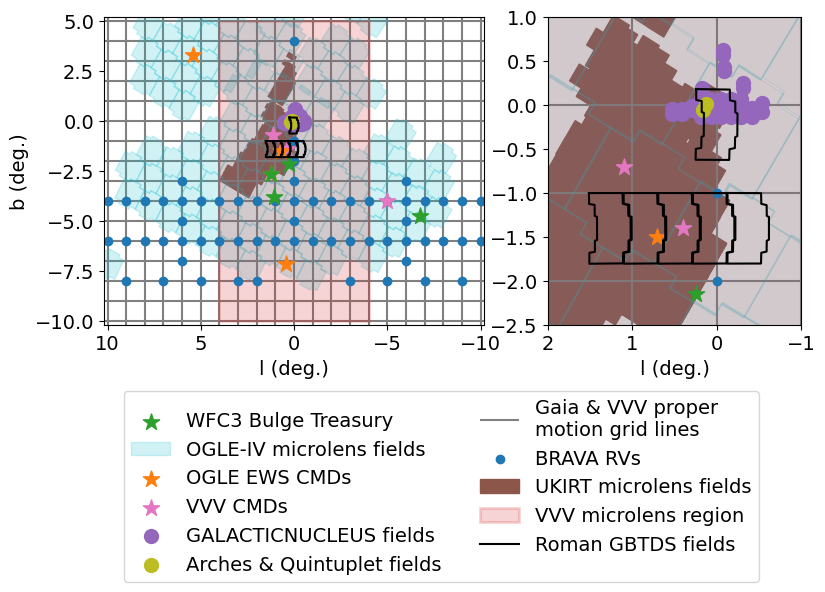

In [132]:
fig,ax = plt.subplots(nrows=1, ncols=2, figsize=(9,4),width_ratios=[3,2])
ax[0].set_ylim(-10.2,5.2)
ax[0].set_xlim(10.2,-10.2)
plt.rcParams.update({'font.size': 14})
new_overguide =  np.loadtxt('../mulens_rates/roman_sp_paper/field_centers_overguide.txt', skiprows=1)
rgbtds = plot_outline(new_overguide)

for axi in ax:
    axi.scatter(wfc3_bulge[:,0], wfc3_bulge[:,1], c='tab:green',marker='*', s=150,zorder=8, label='WFC3 Bulge Treasury')
    for j,f in enumerate(ogle_outlines):
        leg = 'OGLE-IV microlens fields' if j==0 else None
        axi.fill(f[:,0],f[:,1], c='tab:cyan', zorder=-9,alpha=0.2, label=leg)
    axi.scatter(ogle_cmds.l.degree, ogle_cmds.b.degree,marker='*', s=150, c='tab:orange',zorder=7, label='OGLE EWS CMDs')
    axi.scatter(vvv_cmds[:,0], vvv_cmds[:,1], c='tab:pink',marker='*', s=150, label='VVV CMDs')
    axi.scatter(galnuc[0], galnuc[1], c='tab:purple',marker='o',s=100, label='GALACTICNUCLEUS fields')
    axi.scatter(hosek22[:,0], hosek22[:,1], c='tab:olive',marker='o', s=100, label='Arches & Quintuplet fields')
    axi.vlines(range(-10,11), -12,7, color='gray',zorder=-11, label='Gaia & VVV proper\nmotion grid lines')
    axi.hlines(range(-10,6), -12,12, color='gray',zorder=-11)
    axi.scatter(brava_coords.l_deg, brava_coords.b_deg, marker='o',c='tab:blue', label='BRAVA RVs',zorder=0)
    for j,f in enumerate(ukirt_rate.T):
        leg = 'UKIRT microlens fields' if j==0 else None
        axi.fill(f[0]+rot[0], f[1]+rot[1], c='tab:brown', zorder=-800,label=leg)
    axi.fill(vvv_rate[0], vvv_rate[1], lw=2, c='tab:red',alpha=0.2,zorder=-8, label='VVV microlens region')
    for j in range(len(rgbtds)):
        leg = 'Roman GBTDS fields' if j==0 else None
        axi.plot(*rgbtds[j], c='k',label=leg,zorder=20)

ax[1].set_ylim(-2.5,1)
ax[1].set_xlim(2,-1)
ax[0].set_ylabel('b (deg.)')
ax[0].set_xlabel('l (deg.)')
ax[1].set_xlabel('l (deg.)')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(),
          loc='upper center', bbox_to_anchor=(0.5, -0.03), # to the point (0.5, -0.2) in axis coordinates
            ncol=2)

plt.savefig('figures/all_fields.png',bbox_inches='tight')
plt.savefig('figures/all_fields.pdf',bbox_inches='tight')

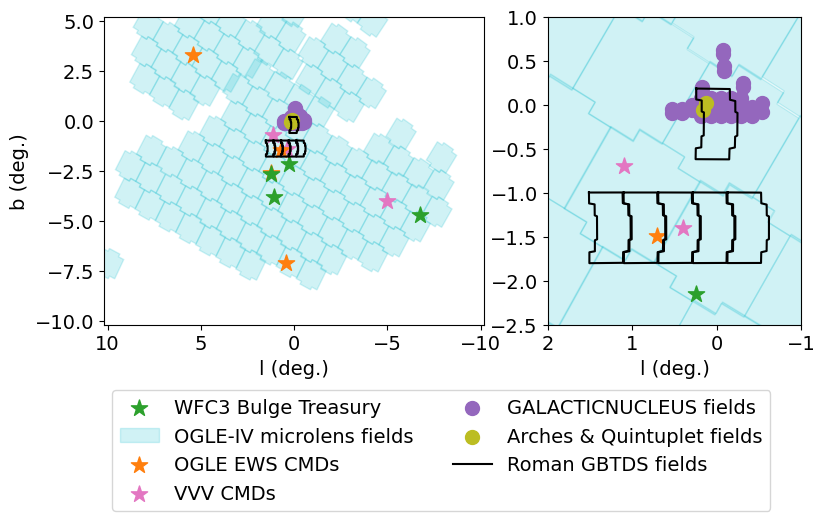

In [131]:
fig,ax = plt.subplots(nrows=1, ncols=2, figsize=(9,4),width_ratios=[3,2])
ax[0].set_ylim(-10.2,5.2)
ax[0].set_xlim(10.2,-10.2)
plt.rcParams.update({'font.size': 14})
new_overguide =  np.loadtxt('../mulens_rates/roman_sp_paper/field_centers_overguide.txt', skiprows=1)
rgbtds = plot_outline(new_overguide)

for axi in ax:
    axi.scatter(wfc3_bulge[:,0], wfc3_bulge[:,1], c='tab:green',marker='*', s=150,zorder=8, label='WFC3 Bulge Treasury')
    for j,f in enumerate(ogle_outlines):
        leg = 'OGLE-IV microlens fields' if j==0 else None
        axi.fill(f[:,0],f[:,1], c='tab:cyan', zorder=-9,alpha=0.2, label=leg)
    axi.scatter(ogle_cmds.l.degree, ogle_cmds.b.degree,marker='*', s=150, c='tab:orange',zorder=7, label='OGLE EWS CMDs')
    axi.scatter(vvv_cmds[:,0], vvv_cmds[:,1], c='tab:pink',marker='*', s=150, label='VVV CMDs')
    axi.scatter(galnuc[0], galnuc[1], c='tab:purple',marker='o',s=100, label='GALACTICNUCLEUS fields')
    axi.scatter(hosek22[:,0], hosek22[:,1], c='tab:olive',marker='o', s=100, label='Arches & Quintuplet fields')
    for j in range(len(rgbtds)):
        leg = 'Roman GBTDS fields' if j==0 else None
        axi.plot(*rgbtds[j], c='k',label=leg,zorder=20)

ax[1].set_ylim(-2.5,1)
ax[1].set_xlim(2,-1)
ax[0].set_ylabel('b (deg.)')
ax[0].set_xlabel('l (deg.)')
ax[1].set_xlabel('l (deg.)')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(),
          loc='upper center', bbox_to_anchor=(0.5, -0.03), # to the point (0.5, -0.2) in axis coordinates
            ncol=2)

plt.savefig('figures/sec3_fields.png',bbox_inches='tight')
plt.savefig('figures/sec3_fields.pdf',bbox_inches='tight')

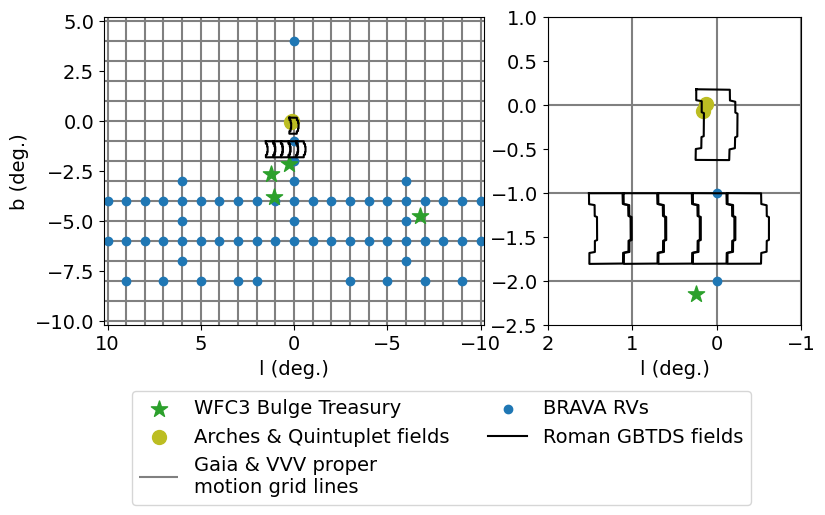

In [130]:
fig,ax = plt.subplots(nrows=1, ncols=2, figsize=(9,4),width_ratios=[3,2])
ax[0].set_ylim(-10.2,5.2)
ax[0].set_xlim(10.2,-10.2)
plt.rcParams.update({'font.size': 14})
new_overguide =  np.loadtxt('../mulens_rates/roman_sp_paper/field_centers_overguide.txt', skiprows=1)
rgbtds = plot_outline(new_overguide)

for axi in ax:
    axi.scatter(wfc3_bulge[:,0], wfc3_bulge[:,1], c='tab:green',marker='*', s=150,zorder=8, label='WFC3 Bulge Treasury')
    axi.scatter(hosek22[:,0], hosek22[:,1], c='tab:olive',marker='o', s=100, label='Arches & Quintuplet fields')
    axi.vlines(range(-10,11), -12,7, color='gray',zorder=-11, label='Gaia & VVV proper\nmotion grid lines')
    axi.hlines(range(-10,6), -12,12, color='gray',zorder=-11)
    axi.scatter(brava_coords.l_deg, brava_coords.b_deg, marker='o',c='tab:blue', label='BRAVA RVs',zorder=0)
    for j in range(len(rgbtds)):
        leg = 'Roman GBTDS fields' if j==0 else None
        axi.plot(*rgbtds[j], c='k',label=leg,zorder=20)

ax[1].set_ylim(-2.5,1)
ax[1].set_xlim(2,-1)
ax[0].set_ylabel('b (deg.)')
ax[0].set_xlabel('l (deg.)')
ax[1].set_xlabel('l (deg.)')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(),
          loc='upper center', bbox_to_anchor=(0.5, -0.03), # to the point (0.5, -0.2) in axis coordinates
            ncol=2)

plt.savefig('figures/sec4_fields.png',bbox_inches='tight')
plt.savefig('figures/sec4_fields.pdf',bbox_inches='tight')

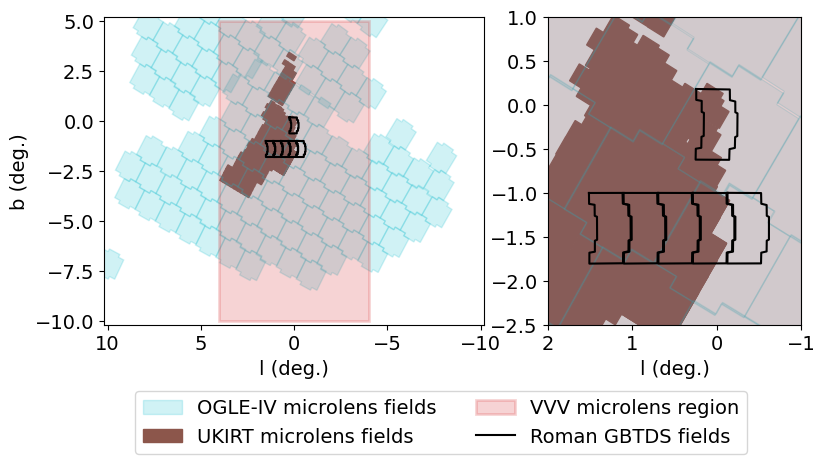

In [129]:
fig,ax = plt.subplots(nrows=1, ncols=2, figsize=(9,4),width_ratios=[3,2])
ax[0].set_ylim(-10.2,5.2)
ax[0].set_xlim(10.2,-10.2)
plt.rcParams.update({'font.size': 14})
new_overguide =  np.loadtxt('../mulens_rates/roman_sp_paper/field_centers_overguide.txt', skiprows=1)
rgbtds = plot_outline(new_overguide)

for axi in ax:
    for j,f in enumerate(ogle_outlines):
        leg = 'OGLE-IV microlens fields' if j==0 else None
        axi.fill(f[:,0],f[:,1], c='tab:cyan', zorder=-9,alpha=0.2, label=leg)
    for j,f in enumerate(ukirt_rate.T):
        leg = 'UKIRT microlens fields' if j==0 else None
        axi.fill(f[0]+rot[0], f[1]+rot[1], c='tab:brown', zorder=-800,label=leg)
    axi.fill(vvv_rate[0], vvv_rate[1], lw=2, c='tab:red',alpha=0.2,zorder=-8, label='VVV microlens region')
    for j in range(len(rgbtds)):
        leg = 'Roman GBTDS fields' if j==0 else None
        axi.plot(*rgbtds[j], c='k',label=leg,zorder=20)

ax[1].set_ylim(-2.5,1)
ax[1].set_xlim(2,-1)
ax[0].set_ylabel('b (deg.)')
ax[0].set_xlabel('l (deg.)')
ax[1].set_xlabel('l (deg.)')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(),
          loc='upper center', bbox_to_anchor=(0.5, -0.03), # to the point (0.5, -0.2) in axis coordinates
            ncol=2)

plt.savefig('figures/sec5_fields.png',bbox_inches='tight')
plt.savefig('figures/sec5_fields.pdf',bbox_inches='tight')